## AGN Homework 4 – Black Hole Mass & Accretion Disk Parameters Estimation

In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl

import matplotlib.pyplot as plt

In [2]:
sample = pd.read_csv('sample.csv')
display(sample.head(11))
print(f'\nSampled Data Frame Length: {len(sample)}\n')

,RAJ2000,DEJ2000,Plate,Fiber,MJD,iMAG,logLbol,e_logLbol,logLBHb,e_logLBHb,W_BHb_,e_W_BHb_,EWBHb,e_EWBHb,SN_Hb_,logBH,e_logBH,logEdd
0,189.67804,45.30687,1372,486,53062,-23.20,45.236,0.004,42.35,0.02,4399.3,330.1,62.0,3.10,23.06,8.33,0.07,-1.20
1,189.77188,41.44564,1984,609,53433,-22.29,44.819,0.005,42.11,0.04,2371.4,541.6,89.4,8.70,15.06,7.59,0.20,-0.87
2,189.81419,53.23740,885,449,52379,-22.69,45.121,0.004,41.93,0.04,10756.6,4366.4,32.1,3.40,16.27,9.05,0.35,-2.03
3,189.93733,19.90707,2614,350,54481,-23.37,45.132,0.001,42.55,0.02,15241.3,362.8,118.7,6.30,19.79,9.36,0.02,-2.33
4,189.99405,49.09448,1278,96,52735,-22.77,45.166,0.011,42.25,0.01,1385.6,48.6,52.5,2.90,15.96,7.29,0.03,-0.23
5,190.05440,31.04537,2237,448,53828,-22.70,45.098,0.005,41.54,0.08,4940.4,2527.9,13.2,3.20,17.40,8.36,0.44,-1.37
6,190.40521,44.74830,1372,589,53062,-22.45,45.066,0.002,41.42,0.03,1506.3,110.8,10.2,0.67,18.00,7.32,0.06,-0.35
7,190.59734,19.78912,2614,279,54481,-22.90,45.099,0.002,42.30,0.02,4480.9,176.4,72.2,3.10,27.18,8.28,0.03,-1.28
8,190.65991,4.93792,846,119,52407,-22.70,45.035,0.004,42.32,0.03,6825.3,345.0,87.4,6.00,17.87,8.61,0.04,-1.68
9,190.84929,5.24622,846,596,52407,-23.07,45.189,0.002,42.41,0.02,3693.9,232.3,77.8,3.10,29.46,8.16,0.05,-1.07



Sampled Data Frame Length: 500



In [3]:
def cleans(df):
    clean = df[['Plate', 'MJD', 'Fiber']].copy()
    clean.columns = ['plate', 'mjd', 'fiber']
    clean.to_csv('clean.txt', sep=' ', index=False)

cleans(sample)

In [4]:
def chunks(df, index = 0, size = 100):
    chunk = df[['Plate', 'MJD', 'Fiber']].copy()
    chunk.columns = ['plate', 'mjd', 'fiber']
    chunk = chunk[index * size : (index + 1) * size]
    print(chunk.to_csv(sep=' ', index=False))

# chunks(sample)

### [Query](https://skyserver.sdss.org/dr19/CrossMatchTools/ObjectCrossID)

```sql
SELECT s.plate, s.mjd, s.fiberid, s.z,
               g.h_beta_flux, g.h_beta_flux_err,
               p.i, p.err_i, p.dered_i, p.r, p.err_r, p.dered_r
FROM #upload u
    JOIN SpecObj s ON (s.plate=u.up_plate AND s.mjd=u.up_mjd AND s.fiberID=u.up_fiber)
    JOIN GalSpecLine g ON g.specobjid=s.specobjid
    JOIN PhotoObj p ON p.specobjid=s.specobjid
```

In [5]:
combine = pd.read_csv(f'combine.csv', skiprows=1)
# combine = pd.concat([pd.read_csv(f'chunks/{i}.csv', skiprows=1) for i in np.arange(5)], ignore_index=True)

display(combine.head(11))
print(f'\nCombined Data Frame Length: {len(combine)}\n')

,plate,mjd,fiberid,z,h_beta_flux,h_beta_flux_err,i,err_i,dered_i,r,err_r,dered_r
0,312,51689,639,0.239911,307.7378,8.212964,17.36864,0.006106,17.25892,17.69872,0.006042,17.55107
1,312,51689,330,0.217196,479.4295,8.923738,17.54849,0.006637,17.46594,17.86044,0.006591,17.74936
2,2246,53767,66,0.086380,2033.9690,18.786320,15.34829,0.003031,15.32908,15.78949,0.003081,15.76364
3,2614,54481,350,0.239360,370.0913,6.064452,17.24088,0.006534,17.19873,17.58044,0.006224,17.52372
4,2614,54481,279,0.160263,778.7159,13.930760,16.28290,0.004258,16.24698,16.62469,0.004492,16.57634
5,592,52025,376,0.126024,926.9399,11.060870,16.04254,0.003917,15.96723,16.81671,0.004317,16.71536
6,2121,54180,631,0.256513,164.8087,5.731501,17.29319,0.006934,17.26627,17.51264,0.005907,17.47642
7,2122,54178,436,0.196369,356.9352,6.805614,17.06529,0.005562,17.04531,17.46406,0.005483,17.43717
8,2122,54178,200,0.297204,268.0277,5.733673,17.70926,0.007241,17.68754,17.90666,0.006517,17.87743
9,2125,53795,432,0.187731,267.1736,6.514564,17.14110,0.005575,17.11856,17.55638,0.005694,17.52605



Combined Data Frame Length: 427



In [6]:
data = pd.merge(sample, combine,
                left_on=['Plate', 'Fiber', 'MJD'],
                right_on=['plate', 'fiberid', 'mjd'])[['Plate',
                                                       'MJD',
                                                       'Fiber',
                                                       'z',
                                                       'h_beta_flux',
                                                       'W_BHb_',
                                                       'dered_i',
                                                       'logLBHb',
                                                       'logBH',
                                                       'logLbol',
                                                       'logEdd']]

data.columns = ['plate',
                'mjd',
                'fiber',
                'z',
                'hbeta_flux',
                'hbeta_br_fwhm',
                'dered_i',
                'lit_log_hbeta_lum',
                'lit_log_bhm',
                'lit_log_bol_lum',
                'lit_log_edd_ratio']

data.insert(loc=10, column='lit_log_edd_lum', value=(data['lit_log_bol_lum'] - data['lit_log_edd_ratio']))

display(data.head(11))
print(f'\nData Frame Length: {len(data)}\n')

,plate,mjd,fiber,z,hbeta_flux,hbeta_br_fwhm,dered_i,lit_log_hbeta_lum,lit_log_bhm,lit_log_bol_lum,lit_log_edd_lum,lit_log_edd_ratio
0,1372,53062,486,0.228846,323.90260,4399.3,16.90558,42.35,8.33,45.236,46.436,-1.20
1,1984,53433,609,0.178252,448.13070,2371.4,17.27254,42.11,7.59,44.819,45.689,-0.87
2,885,52379,449,0.201624,86.80108,10756.6,15.91479,41.93,9.05,45.121,47.151,-2.03
3,2614,54481,350,0.239360,370.09130,15241.3,17.19873,42.55,9.36,45.132,47.462,-2.33
4,1278,52735,96,0.235311,589.24180,1385.6,17.84571,42.25,7.29,45.166,45.396,-0.23
5,2237,53828,448,0.235612,43.81033,4940.4,17.09939,41.54,8.36,45.098,46.468,-1.37
6,1372,53062,589,0.191827,240.50850,1506.3,17.35610,41.42,7.32,45.066,45.416,-0.35
7,2614,54481,279,0.160263,778.71590,4480.9,16.24698,42.30,8.28,45.099,46.379,-1.28
8,846,52407,119,0.233455,155.72050,6825.3,17.65136,42.32,8.61,45.035,46.715,-1.68
9,846,52407,596,0.164745,703.11630,3693.9,16.24184,42.41,8.16,45.189,46.259,-1.07



Data Frame Length: 427



<>:29: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:29: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_14390/215776744.py:29: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  axes[2].set_ylabel('Dereddened $i$-band Magnitude ($\mathrm{mag}$)')


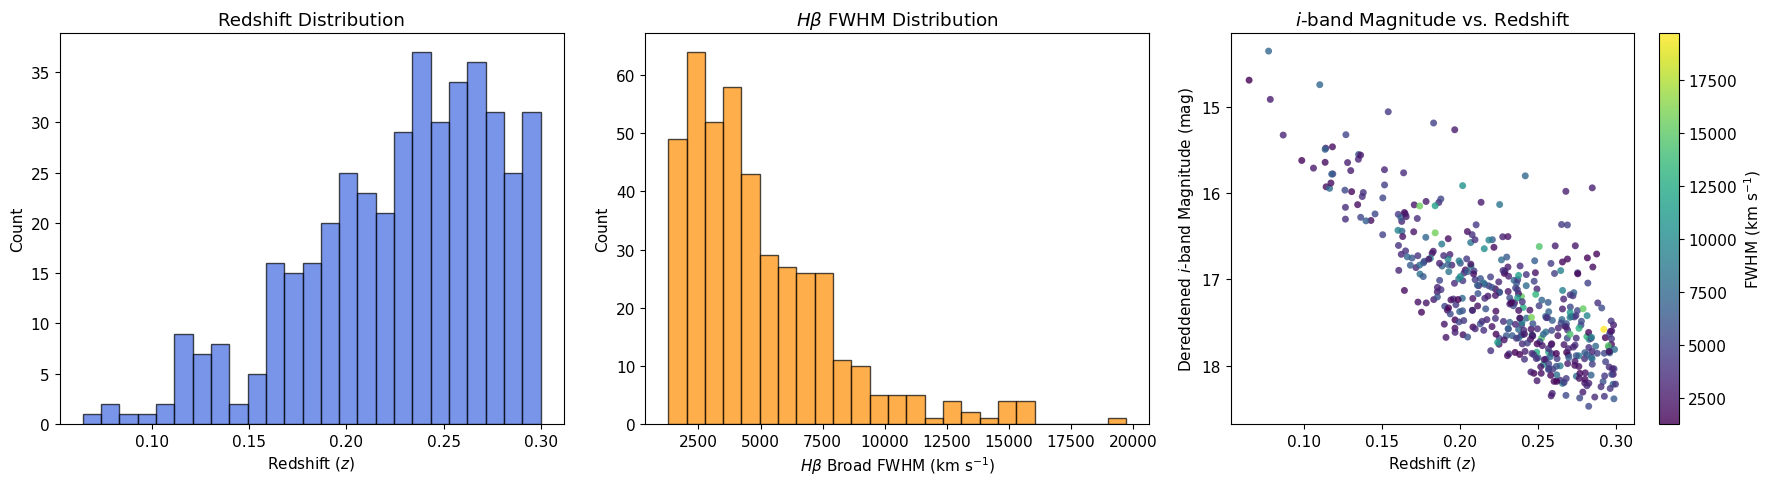

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set plotting aesthetics
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
#plt.style.use('seaborn-v0_8-whitegrid') if 'seaborn-v0_8-whitegrid' in plt.style.available else plt.style.use('default')

# Create a figure with 3 subplots side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Redshift Distribution
axes[0].hist(data['z'], bins=25, color='royalblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Redshift ($z$)')
axes[0].set_ylabel('Count')
axes[0].set_title('Redshift Distribution')

# 2. Hβ Broad FWHM Distribution
axes[1].hist(data['hbeta_br_fwhm'], bins=25, color='darkorange', edgecolor='black', alpha=0.7)
axes[1].set_xlabel(r'$H\beta$ Broad FWHM ($\mathrm{km\ s}^{-1}$)')
axes[1].set_ylabel('Count')
axes[1].set_title(r'$H\beta$ FWHM Distribution')

# 3. i-band Magnitude vs Redshift (Using dereddened i-band magnitude)
scatter = axes[2].scatter(data['z'], data['dered_i'], c=data['hbeta_br_fwhm'], 
                           cmap='viridis', alpha=0.8, edgecolors='none', s=25)
axes[2].set_xlabel('Redshift ($z$)')
axes[2].set_ylabel('Dereddened $i$-band Magnitude ($\mathrm{mag}$)')
axes[2].invert_yaxis() # Magnitudes are inverted (brighter at top)
axes[2].set_title('$i$-band Magnitude vs. Redshift')
cbar = fig.colorbar(scatter, ax=axes[2])
cbar.set_label(r'FWHM ($\mathrm{km\ s}^{-1}$)')

plt.tight_layout()
plt.show()

In [8]:
# Constants
H0 = 67.8              # km/s/Mpc
Omega_m = 0.31
Omega_L = 0.69
c = 299792.458         # km/s
Mpc_to_cm = 3.08567758e24
FLUX_SCALE = 1e-17     # Standard SDSS line flux unit scaling factor

def get_luminosity_distance(z, H0=H0, Om=Omega_m, Ol=Omega_L):
    if z <= 0:
        return 0.0
    # Numerical integration using trapezoidal rule for E(z)
    z_grid = np.linspace(0, z, 1000)
    E = np.sqrt(Om * (1 + z_grid)**3 + Ol)
    comoving_integral = np.trapezoid(1.0 / E, z_grid)
    
    # Comoving distance (Mpc) -> Luminosity Distance (Mpc)
    D_C = (c / H0) * comoving_integral
    D_L = (1 + z) * D_C
    return D_L

# 1. Calculate Luminosity Distance in Mpc and cm
data['D_L_Mpc'] = data['z'].apply(get_luminosity_distance)
data['D_L_cm'] = data['D_L_Mpc'] * Mpc_to_cm

# 2. Calculate Hβ Line Luminosity (erg/s)
# L = 4 * pi * D_L^2 * Flux
data['L_hbeta'] = 4 * np.pi * (data['D_L_cm']**2) * (data['hbeta_flux'] * FLUX_SCALE)

# 3. Calculate Black Hole Mass via Wu (2009) / Greene & Ho (2005) scaling relation
# log10(M_BH/M_sun) = a + b * log10(L_Hbeta / 10^42) + c * log10(FWHM / 1000)
# Adjust a, b, c constants here if your course text explicitly dictates variant calibrations.
a, b, c_coeff = 4.40, 0.56, 2.0

data['log_MBH'] = a + b * np.log10(data['L_hbeta'] / 1e42) + c_coeff * np.log10(data['hbeta_br_fwhm'] / 1000.0)
data['MBH'] = 10**data['log_MBH']

# 4. Calculate Bolometric Luminosity, Eddington Luminosity, and Eddington Ratio
# Standard linear bolometric correction factor from line luminosity (Wu 2009 / Greene & Ho)
BOL_CORRECTION = 115.0 
data['L_bol'] = data['L_hbeta'] * BOL_CORRECTION

# L_edd = 1.26e38 * (M_BH / M_sun) erg/s
data['L_edd'] = 1.26e38 * data['MBH']
data['edd_ratio'] = data['L_bol'] / data['L_edd']

print("Calculations complete. Sample summary:")
print(data[['z', 'L_hbeta', 'log_MBH', 'edd_ratio']].describe().loc[['mean', 'min', 'max']])

Calculations complete. Sample summary:
             z       L_hbeta   log_MBH  edd_ratio
mean  0.227720  7.159632e+41  5.442081   3.657933
min   0.064495  2.805250e+40  4.435308   0.032354
max   0.299768  8.609204e+42  6.671088  31.839535


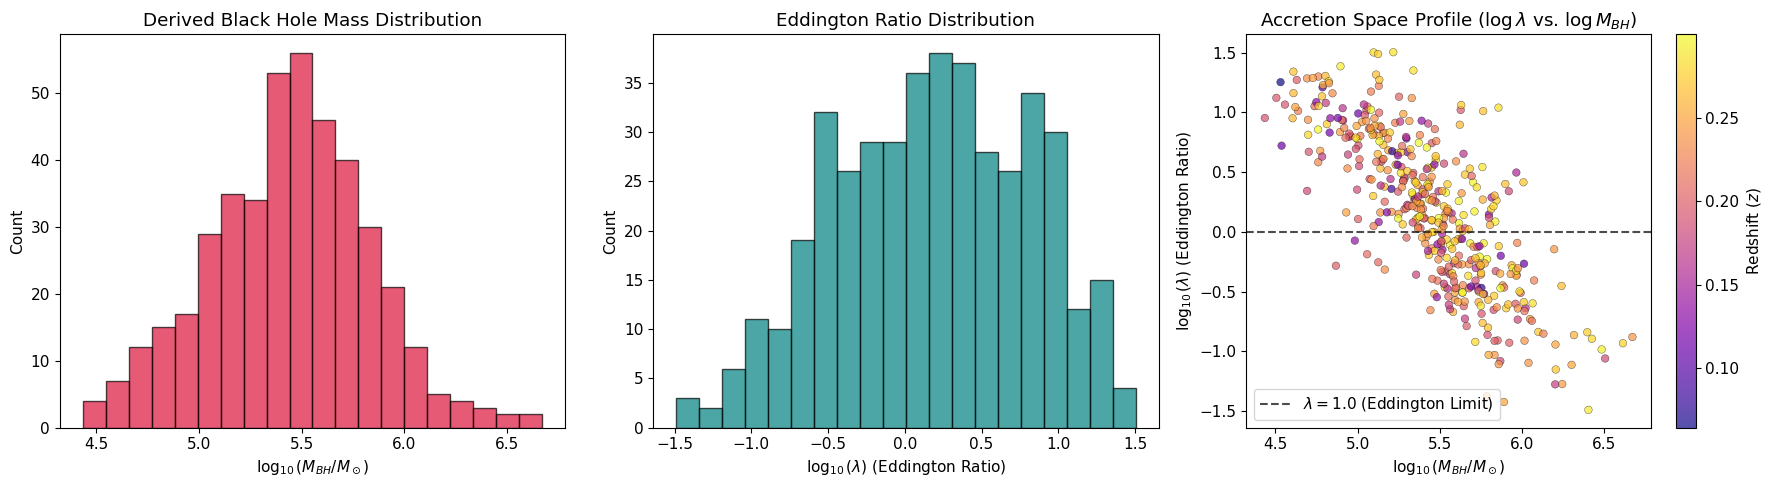

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Black Hole Mass Histogram
axes[0].hist(data['log_MBH'], bins=20, color='crimson', edgecolor='black', alpha=0.7)
axes[0].set_xlabel(r'$\log_{10}(M_{BH} / M_\odot)$')
axes[0].set_ylabel('Count')
axes[0].set_title('Derived Black Hole Mass Distribution')

# 2. Eddington Ratio Histogram
axes[1].hist(np.log10(data['edd_ratio']), bins=20, color='teal', edgecolor='black', alpha=0.7)
axes[1].set_xlabel(r'$\log_{10}(\lambda)$ (Eddington Ratio)')
axes[1].set_ylabel('Count')
axes[1].set_title('Eddington Ratio Distribution')

# 3. Diagnostic Plot: Eddington Ratio vs Black Hole Mass
scatter = axes[2].scatter(data['log_MBH'], np.log10(data['edd_ratio']), c=data['z'], 
                           cmap='plasma', alpha=0.7, edgecolors='black', linewidths=0.3, s=30)
axes[2].set_xlabel(r'$\log_{10}(M_{BH} / M_\odot)$')
axes[2].set_ylabel(r'$\log_{10}(\lambda)$ (Eddington Ratio)')
axes[2].set_title(r'Accretion Space Profile ($\log \lambda$ vs. $\log M_{BH}$)')

# Add constant Eddington limit marker reference lines
axes[2].axhline(0, color='black', linestyle='--', alpha=0.7, label=r'$\lambda = 1.0$ (Eddington Limit)')
axes[2].legend(loc='lower left')

cbar = fig.colorbar(scatter, ax=axes[2])
cbar.set_label('Redshift ($z$)')

plt.tight_layout()
plt.show()

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def generate_clean_corner(df, x_param, y_param, x_label=None, y_label=None, bins=25, cmap='Blues'):
    """
    Generates a clean 2x2 corner plot for two parameters using only pyplot.
    
    Upper-Right: Hidden
    Lower-Left: 2D Histogram
    Upper-Left: 1D Histogram for X-axis parameter (aligned vertically)
    Lower-Right: 1D Histogram for Y-axis parameter (oriented horizontally)
    """
    # Create a 2x2 grid sharing axes across columns and rows respectively
    fig, axes = plt.subplots(2, 2, figsize=(8, 8), sharex='col', sharey='row')
    
    ax_histx = axes[0, 0]
    ax_hide  = axes[0, 1]
    ax_2d    = axes[1, 0]
    ax_histy = axes[1, 1]
    
    # 1. Hide the upper right square completely
    ax_hide.set_visible(False)
    
    # 2. Top-Left: 1D Histogram for X
    ax_histx.hist(df[x_param], bins=bins, color='gainsboro', edgecolor='dimgray', linewidth=0.8)
    ax_histx.set_ylabel('Count', fontsize=10)
    ax_histx.spines['top'].set_visible(False)
    ax_histx.spines['right'].set_visible(False)
    ax_histx.tick_params(axis='x', which='both', bottom=True, labelbottom=False)
    
    # 3. Bottom-Left: 2D Histogram
    # cmin=1 leaves background cells empty/white rather than a solid background block
    counts, xedges, yedges, im = ax_2d.hist2d(df[x_param], df[y_param], bins=bins, cmap=cmap, cmin=1)
    ax_2d.set_xlabel(x_label if x_label else x_param, fontsize=11)
    ax_2d.set_ylabel(y_label if y_label else y_param, fontsize=11)
    
    # 4. Bottom-Right: 1D Histogram for Y (oriented horizontally to align with the 2D plot)
    ax_histy.hist(df[y_param], bins=bins, orientation='horizontal', color='gainsboro', edgecolor='dimgray', linewidth=0.8)
    ax_histy.set_xlabel('Count', fontsize=10)
    ax_histy.spines['top'].set_visible(False)
    ax_histy.spines['right'].set_visible(False)
    ax_histy.tick_params(axis='y', which='both', left=True, labelleft=False)
    
    # Compress padding to bring subplots tightly together like a standard corner plot
    plt.subplots_adjust(hspace=0.06, wspace=0.06)
    
    return fig, axes

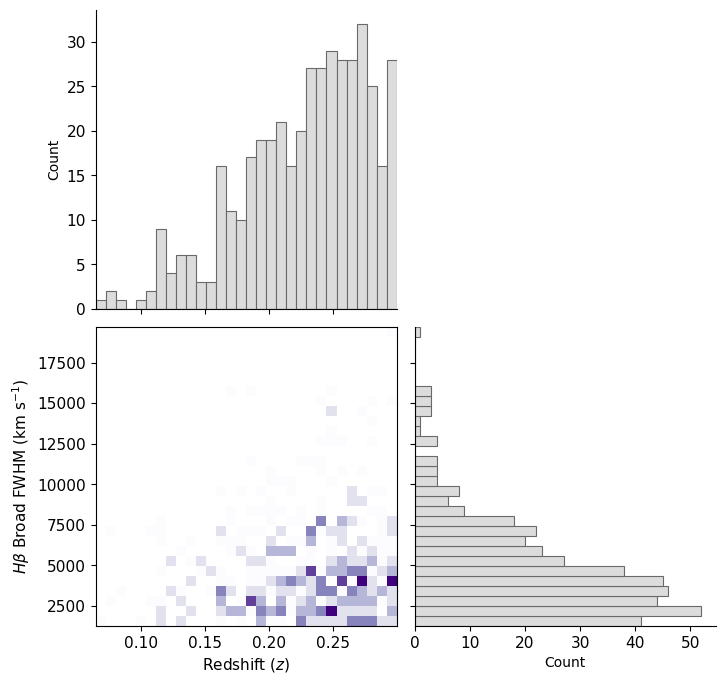

In [11]:
# Generate the corner plot specifically for z and hbeta_br_fwhm
fig, axes = generate_clean_corner(
    df=data, 
    x_param='z', 
    y_param='hbeta_br_fwhm',
    x_label='Redshift ($z$)', 
    y_label=r'$H\beta$ Broad FWHM ($\mathrm{km\ s}^{-1}$)',
    bins=30,
    cmap='Purples'
)

# Display the final custom visualization
plt.show()

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def generate_clean_corner(df, x_param, y_param, x_label=None, y_label=None, bins=25, cmap='Blues', scale='linear'):
    """
    Generates a clean 2x2 corner plot for two parameters using only pyplot.
    Supports both 'linear' and 'log' scaling with appropriately scaled bins.
    """
    # Clean out missing values to ensure accurate bin limits
    valid_data = df[[x_param, y_param]].dropna()
    
    if scale == 'log':
        # Drop zero or negative values if log scale is requested
        valid_data = valid_data[(valid_data[x_param] > 0) & (valid_data[y_param] > 0)]
        
        # Calculate geometrically uniform bins for log scale
        xbins = np.logspace(np.log10(valid_data[x_param].min()), np.log10(valid_data[x_param].max()), bins + 1)
        ybins = np.logspace(np.log10(valid_data[y_param].min()), np.log10(valid_data[y_param].max()), bins + 1)
    else:
        # Calculate linearly uniform bins
        xbins = np.linspace(valid_data[x_param].min(), valid_data[x_param].max(), bins + 1)
        ybins = np.linspace(valid_data[y_param].min(), valid_data[y_param].max(), bins + 1)

    # Create a 2x2 grid sharing axes
    fig, axes = plt.subplots(2, 2, figsize=(8, 8), sharex='col', sharey='row')
    
    ax_histx = axes[0, 0]
    ax_hide  = axes[0, 1]
    ax_2d    = axes[1, 0]
    ax_histy = axes[1, 1]
    
    # Hide the upper right block
    ax_hide.set_visible(False)
    
    # Apply log scaling to the core 2D plot (will propagate to shared 1D axes automatically)
    if scale == 'log':
        ax_2d.set_xscale('log')
        ax_2d.set_yscale('log')
    
    # 1. Top-Left: 1D Histogram for X
    ax_histx.hist(valid_data[x_param], bins=xbins, color='gainsboro', edgecolor='dimgray', linewidth=0.8)
    ax_histx.set_ylabel('Count', fontsize=10)
    ax_histx.spines['top'].set_visible(False)
    ax_histx.spines['right'].set_visible(False)
    ax_histx.tick_params(axis='x', which='both', bottom=True, labelbottom=False)
    
    # 2. Bottom-Left: 2D Histogram (Pass custom [xbins, ybins] arrays)
    ax_2d.hist2d(valid_data[x_param], valid_data[y_param], bins=[xbins, ybins], cmap=cmap, cmin=1)
    ax_2d.set_xlabel(x_label if x_label else x_param, fontsize=11)
    ax_2d.set_ylabel(y_label if y_label else y_param, fontsize=11)
    
    # 3. Bottom-Right: 1D Histogram for Y (Horizontal)
    ax_histy.hist(valid_data[y_param], bins=ybins, orientation='horizontal', color='gainsboro', edgecolor='dimgray', linewidth=0.8)
    ax_histy.set_xlabel('Count', fontsize=10)
    ax_histy.spines['top'].set_visible(False)
    ax_histy.spines['right'].set_visible(False)
    ax_histy.tick_params(axis='y', which='both', left=True, labelleft=False)
    
    # Adjust spacing for tight corner-plot alignment
    plt.subplots_adjust(hspace=0.06, wspace=0.06)
    
    return fig, axes

<>:6: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:6: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/tmp/ipykernel_14390/1063417986.py:6: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  x_label='Redshift ($\log_{10}\ z$)',


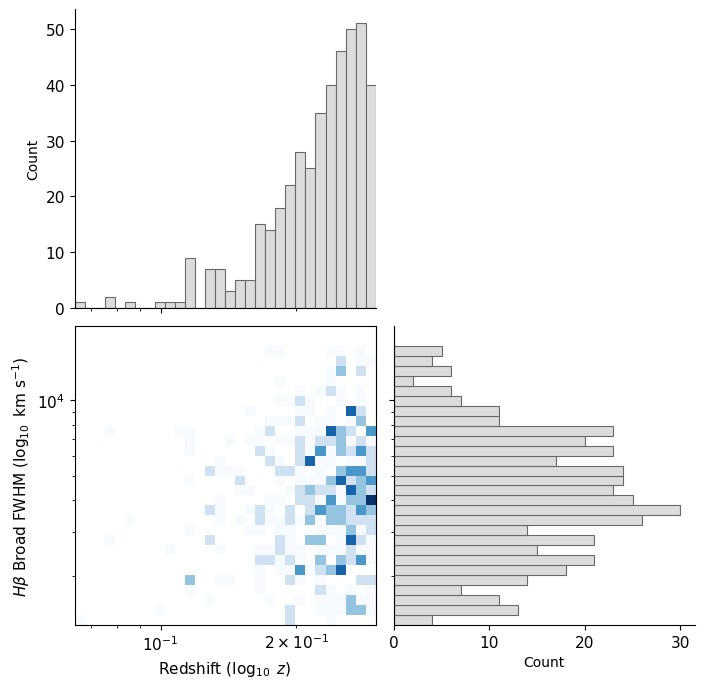

In [13]:
# Generate the corner plot with log scaling active
fig, axes = generate_clean_corner(
    df=data, 
    x_param='z', 
    y_param='hbeta_br_fwhm',
    x_label='Redshift ($\log_{10}\ z$)', 
    y_label=r'$H\beta$ Broad FWHM ($\log_{10}\ \mathrm{km\ s}^{-1}$)',
    bins=30,
    cmap='Blues',
    scale='log'
)

plt.show()

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def generate_clean_corner(df, x_param, y_param, x_label=None, y_label=None, bins=25, cmap='Blues', xscale='linear', yscale='linear'):
    """
    Generates a clean 2x2 corner plot for two parameters using only pyplot.
    Allows independent scaling ('linear' or 'log') for the X and Y axes.
    """
    # 1. Filter out missing data
    valid_data = df[[x_param, y_param]].dropna()
    
    # 2. Handle non-positive values for log scales if applicable
    if xscale == 'log':
        valid_data = valid_data[valid_data[x_param] > 0]
    if yscale == 'log':
        valid_data = valid_data[valid_data[y_param] > 0]
        
    # 3. Compute X-axis bins based on chosen scale
    if xscale == 'log':
        xbins = np.logspace(np.log10(valid_data[x_param].min()), np.log10(valid_data[x_param].max()), bins + 1)
    else:
        xbins = np.linspace(valid_data[x_param].min(), valid_data[x_param].max(), bins + 1)
        
    # 4. Compute Y-axis bins based on chosen scale
    if yscale == 'log':
        ybins = np.logspace(np.log10(valid_data[y_param].min()), np.log10(valid_data[y_param].max()), bins + 1)
    else:
        ybins = np.linspace(valid_data[y_param].min(), valid_data[y_param].max(), bins + 1)

    # 5. Create the 2x2 grid with shared axes
    fig, axes = plt.subplots(2, 2, figsize=(8, 8), sharex='col', sharey='row')
    
    ax_histx = axes[0, 0]
    ax_hide  = axes[0, 1]
    ax_2d    = axes[1, 0]
    ax_histy = axes[1, 1]
    
    # Hide empty top-right plot
    ax_hide.set_visible(False)
    
    # 6. Apply scale configurations independently
    if xscale == 'log':
        ax_2d.set_xscale('log')
    if yscale == 'log':
        ax_2d.set_yscale('log')
    
    # 7. Plot Top-Left: 1D Histogram for X
    ax_histx.hist(valid_data[x_param], bins=xbins, color='gainsboro', edgecolor='dimgray', linewidth=0.8)
    ax_histx.set_ylabel('Count', fontsize=10)
    ax_histx.spines['top'].set_visible(False)
    ax_histx.spines['right'].set_visible(False)
    ax_histx.tick_params(axis='x', which='both', bottom=True, labelbottom=False)
    
    # 8. Plot Bottom-Left: 2D Histogram
    ax_2d.hist2d(valid_data[x_param], valid_data[y_param], bins=[xbins, ybins], cmap=cmap, cmin=1)
    ax_2d.set_xlabel(x_label if x_label else x_param, fontsize=11)
    ax_2d.set_ylabel(y_label if y_label else y_param, fontsize=11)
    
    # 9. Plot Bottom-Right: 1D Histogram for Y (Horizontal)
    ax_histy.hist(valid_data[y_param], bins=ybins, orientation='horizontal', color='gainsboro', edgecolor='dimgray', linewidth=0.8)
    ax_histy.set_xlabel('Count', fontsize=10)
    ax_histy.spines['top'].set_visible(False)
    ax_histy.spines['right'].set_visible(False)
    ax_histy.tick_params(axis='y', which='both', left=True, labelleft=False)
    
    # Adjust subplot compression layout
    plt.subplots_adjust(hspace=0.06, wspace=0.06)
    
    return fig, axes

<>:6: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:6: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/tmp/ipykernel_14390/1828711881.py:6: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  x_label='Redshift ($\log_{10}\ z$)',


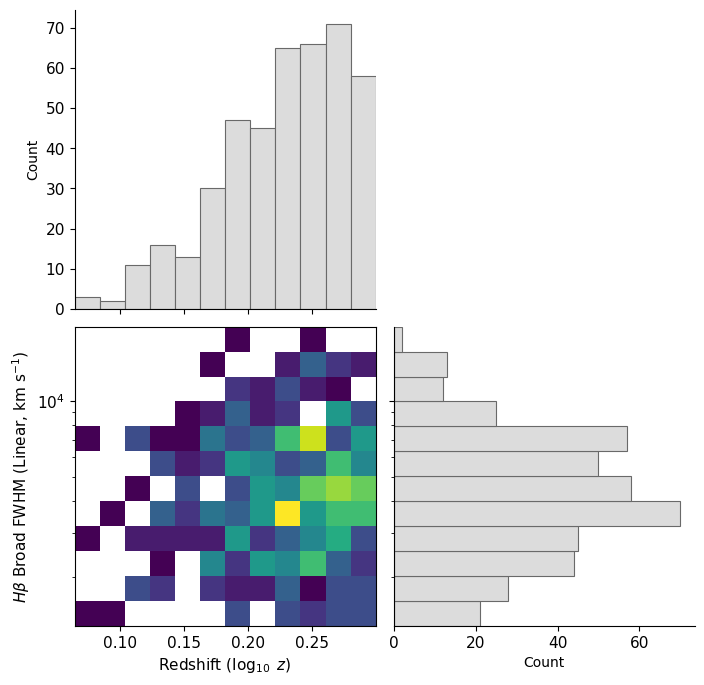

In [15]:
# Generate a corner plot using mixed axis scaling properties
fig, axes = generate_clean_corner(
    df=data, 
    x_param='z', 
    y_param='hbeta_br_fwhm',
    x_label='Redshift ($\log_{10}\ z$)', 
    y_label=r'$H\beta$ Broad FWHM (Linear, $\mathrm{km\ s}^{-1}$)',
    bins=12,
    cmap='viridis',
    xscale='linear',      # X-Axis set to Logarithmic
    yscale='log'    # Y-Axis left as Linear
)

plt.show()

In [16]:
data

,plate,mjd,fiber,z,hbeta_flux,hbeta_br_fwhm,dered_i,lit_log_hbeta_lum,lit_log_bhm,lit_log_bol_lum,lit_log_edd_lum,lit_log_edd_ratio,D_L_Mpc,D_L_cm,L_hbeta,log_MBH,MBH,L_bol,L_edd,edd_ratio
0,1372,53062,486,0.228846,323.90260,4399.3,16.90558,42.35,8.33,45.236,46.436,-1.20,1175.128116,3.626066e+27,5.351750e+41,5.534725,3.425507e+05,6.154513e+43,4.316138e+43,1.425930
1,1984,53433,609,0.178252,448.13070,2371.4,17.27254,42.11,7.59,44.819,45.689,-0.87,889.116854,2.743528e+27,4.238706e+41,4.941260,8.734948e+04,4.874512e+43,1.100603e+43,4.428945
2,885,52379,449,0.201624,86.80108,10756.6,15.91479,41.93,9.05,45.121,47.151,-2.03,1019.537956,3.145965e+27,1.079550e+41,5.921966,8.355377e+05,1.241483e+43,1.052778e+44,0.117925
3,2614,54481,350,0.239360,370.09130,15241.3,17.19873,42.55,9.36,45.132,47.462,-2.33,1236.253620,3.814680e+27,6.767605e+41,6.671088,4.689080e+06,7.782745e+43,5.908240e+44,0.131727
4,1278,52735,96,0.235311,589.24180,1385.6,17.84571,42.25,7.29,45.166,45.396,-0.23,1212.643650,3.741827e+27,1.036742e+42,4.692051,4.920978e+04,1.192254e+44,6.200433e+42,19.228559
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
422,1846,54173,28,0.284370,118.15860,9345.2,17.67022,42.56,9.08,45.423,47.183,-1.76,1504.242989,4.641609e+27,3.198986e+41,6.063984,1.158735e+06,3.678833e+43,1.460006e+44,0.251974
423,2160,53885,444,0.236137,324.73740,4363.7,17.68167,42.19,8.20,44.989,46.299,-1.31,1217.458164,3.756683e+27,5.759057e+41,5.545507,3.511612e+05,6.622915e+43,4.424631e+43,1.496829
424,1650,53174,545,0.273973,2162.26000,2572.5,16.61069,43.14,8.19,45.891,46.291,-0.40,1441.446552,4.447839e+27,5.375464e+42,5.629744,4.263278e+05,6.181784e+44,5.371731e+43,11.507992
425,1354,52814,466,0.249451,252.49410,1559.7,17.74624,41.80,7.38,45.143,45.483,-0.34,1295.457377,3.997364e+27,5.070006e+41,4.620887,4.177215e+04,5.830507e+43,5.263291e+42,11.077681


<>:6: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:6: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/tmp/ipykernel_14390/1169652569.py:6: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  x_label='Redshift ($\log_{10}\ z$)',


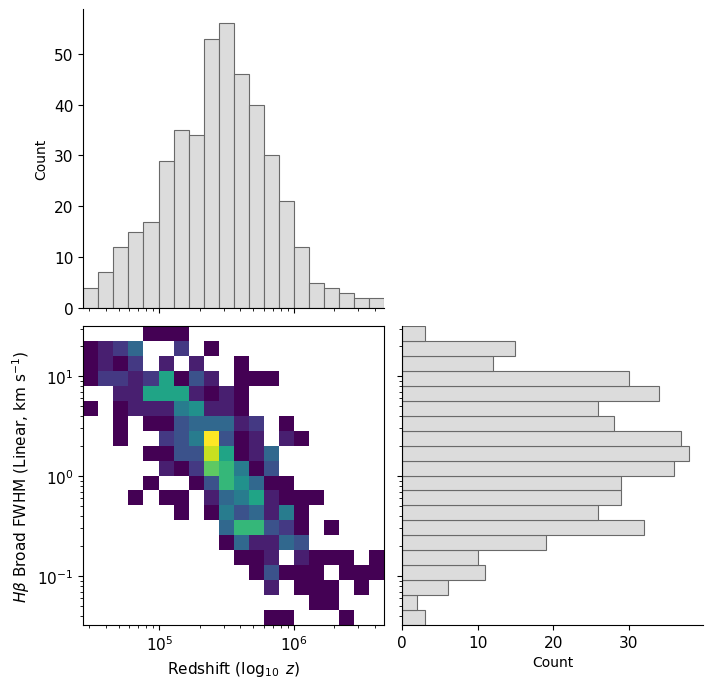

In [17]:
# Generate a corner plot using mixed axis scaling properties
fig, axes = generate_clean_corner(
    df=data, 
    x_param='MBH', 
    y_param='edd_ratio',
    x_label='Redshift ($\log_{10}\ z$)', 
    y_label=r'$H\beta$ Broad FWHM (Linear, $\mathrm{km\ s}^{-1}$)',
    bins=20,
    cmap='viridis',
    xscale='log',      # X-Axis set to Logarithmic
    yscale='log'    # Y-Axis left as Linear
)

plt.show()

<>:22: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:23: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:31: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:32: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:40: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:22: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:23: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences wil

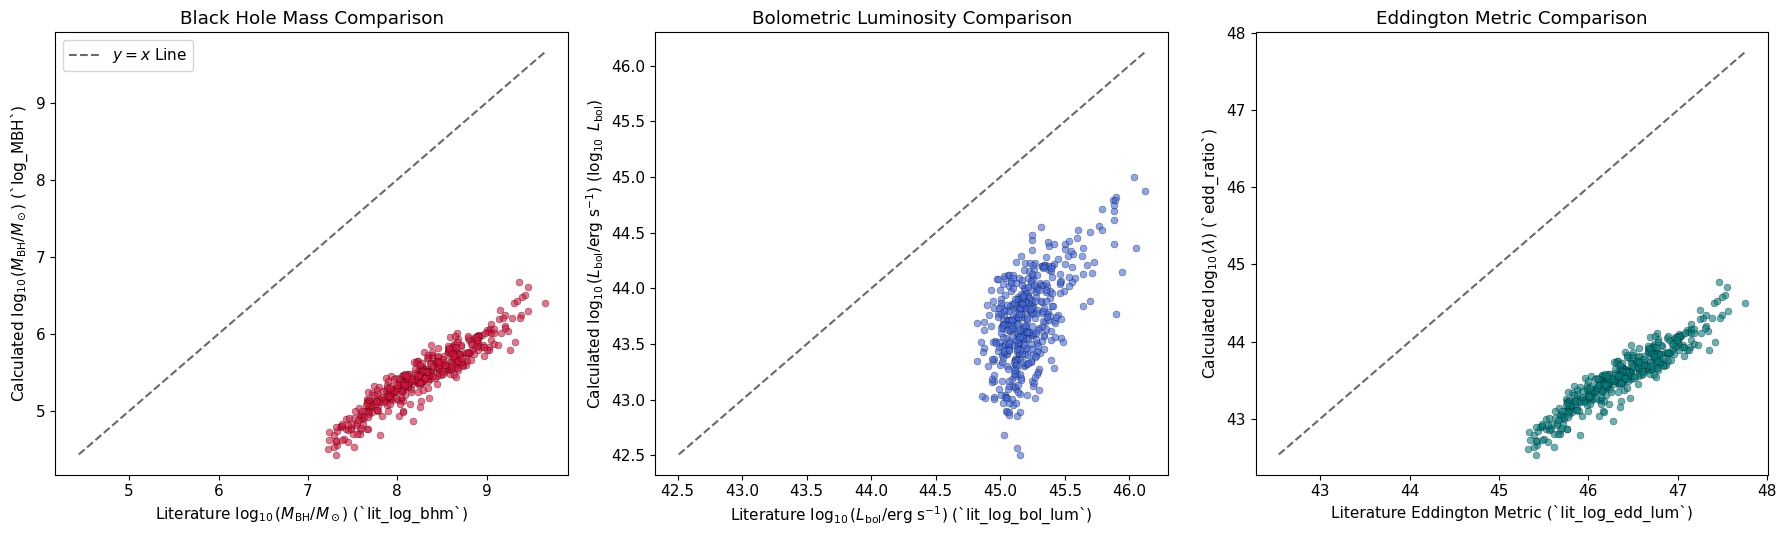

Mean Absolute Deviation for log(M_BH): 2.826 dex
Mean Absolute Deviation for log(L_bol): 1.498 dex
Mean Absolute Deviation for Eddington Space: 2.826 dex


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Extract literature reference values from the 'data' DataFrame
ref_log_mbh = data['lit_log_bhm']
ref_log_lbol = data['lit_log_bol_lum']
ref_log_edd = data['lit_log_edd_lum']

# Extract our calculated values
calc_log_mbh = data['log_MBH']
calc_log_lbol = np.log10(data['L_bol'])
calc_log_edd = np.log10(data['L_edd'])

# Initialize a 1x3 subplot panel
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# 1. Black Hole Mass Comparison
axes[0].scatter(ref_log_mbh, calc_log_mbh, color='crimson', alpha=0.6, edgecolors='black', linewidths=0.3, s=25)
mn, mx = min(ref_log_mbh.min(), calc_log_mbh.min()), max(ref_log_mbh.max(), calc_log_mbh.max())
axes[0].plot([mn, mx], [mn, mx], color='dimgray', linestyle='--', linewidth=1.5, label='$y = x$ Line')
axes[0].set_xlabel('Literature $\log_{10}(M_{\mathrm{BH}} / M_\odot)$ (`lit_log_bhm`)')
axes[0].set_ylabel('Calculated $\log_{10}(M_{\mathrm{BH}} / M_\odot)$ (`log_MBH`)')
axes[0].set_title('Black Hole Mass Comparison')
axes[0].legend(loc='upper left')

# 2. Bolometric Luminosity Comparison
axes[1].scatter(ref_log_lbol, calc_log_lbol, color='royalblue', alpha=0.6, edgecolors='black', linewidths=0.3, s=25)
mn, mx = min(ref_log_lbol.min(), calc_log_lbol.min()), max(ref_log_lbol.max(), calc_log_lbol.max())
axes[1].plot([mn, mx], [mn, mx], color='dimgray', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Literature $\log_{10}(L_{\mathrm{bol}} / \mathrm{erg\ s}^{-1})$ (`lit_log_bol_lum`)')
axes[1].set_ylabel('Calculated $\log_{10}(L_{\mathrm{bol}} / \mathrm{erg\ s}^{-1})$ ($\log_{10}\ L_{\mathrm{bol}}$)')
axes[1].set_title('Bolometric Luminosity Comparison')

# 3. Eddington Metric Comparison
axes[2].scatter(ref_log_edd, calc_log_edd, color='teal', alpha=0.6, edgecolors='black', linewidths=0.3, s=25)
mn, mx = min(ref_log_edd.min(), calc_log_edd.min()), max(ref_log_edd.max(), calc_log_edd.max())
axes[2].plot([mn, mx], [mn, mx], color='dimgray', linestyle='--', linewidth=1.5)
axes[2].set_xlabel('Literature Eddington Metric (`lit_log_edd_lum`)')
axes[2].set_ylabel('Calculated $\log_{10}(\lambda)$ (`edd_ratio`)')
axes[2].set_title('Eddington Metric Comparison')

plt.tight_layout()
plt.show()

# Quantify accuracy via Mean Absolute Deviation (MAD)
mad_mbh = np.mean(np.abs(calc_log_mbh - ref_log_mbh))
mad_lbol = np.mean(np.abs(calc_log_lbol - ref_log_lbol))
mad_edd = np.mean(np.abs(calc_log_edd - ref_log_edd))

print(f"Mean Absolute Deviation for log(M_BH): {mad_mbh:.3f} dex")
print(f"Mean Absolute Deviation for log(L_bol): {mad_lbol:.3f} dex")
print(f"Mean Absolute Deviation for Eddington Space: {mad_edd:.3f} dex")

In [19]:
select = pd.read_table('select.tab')

select

,source,z,log_mbh,log_edd_ratio,app_mag_r,gal_ext_r
0,3C 48,0.369,8.8,-0.30,15.555,0.095
1,3C 186,1.063,8.9,−0.30,17.200,0.109
2,3C 213.1,0.194,9.1,-0.42,18.390,0.065
3,3C 286,0.849,8.5,−0.09,16.500,0.025
4,3C 293,0.045,8.0,−1.78,13.410,0.036
5,3C 309.1,0.905,9.1,−0.45,16.400,0.053
6,3C 346,0.162,8.8,−2.54,16.730,0.147
7,PKS 1549-79,0.152,8.0,−0.32,17.330,0.444
8,PKS 2004-447,0.240,7.6,−0.26,17.674,0.072
9,B1550+5815,1.320,8.9,−0.65,15.600,0.028


In [20]:
import numpy as np
import pandas as pd

# 1. Define cosmological constants (adjust to match your previous notebook cells if needed)
c = 299792.458    # Speed of light in km/s
H0 = 70.0         # Hubble constant in km/s/Mpc
Omega_m = 0.3     # Matter density
Omega_L = 0.7     # Dark energy density ($\Omega_\Lambda$)

# 2. Function to compute DL for a single redshift using full numerical integration
def manual_dl(z):
    if z <= 0:
        return 0.0
    
    # Create a fine grid of z' from 0 to the target redshift z
    z_grid = np.linspace(0, z, 2000)
    
    # Evaluate the expansion integrand: 1 / E(z)
    integrand = 1.0 / np.sqrt(Omega_m * (1 + z_grid)**3 + Omega_L)
    
    # Fully integrate across the grid using np.trapezoid
    comoving_integral = np.trapezoid(integrand, z_grid)
    
    # Complete the Luminosity Distance calculation
    return (1 + z) * (c / H0) * comoving_integral

# 3. Apply the integration to get DL for every row in the 'select' DataFrame
select['DL'] = select['z'].apply(manual_dl)

# 4. Calculate the K-correction column (using alpha = 0.5)
# Formula: K = -2.5 * (1 - alpha) * log10(1 + z) -> simplifies to -1.25 * log10(1 + z)
select['k_corr'] = -1.25 * np.log10(1 + select['z'])

# 5. Compute the final Absolute Magnitude column
select['abs_mag_r'] = (
    select['app_mag_r'] 
    - 5 * np.log10(select['DL']) 
    - 25 
    - select['gal_ext_r'] 
    - select['k_corr']
)

# Preview your updated dataframe
print(select[['z', 'DL', 'k_corr', 'abs_mag_r']])

       z           DL    k_corr  abs_mag_r
0  0.369  1975.472595 -0.170504 -25.847851
1  1.063  7126.247519 -0.393124 -26.780180
2  0.194   947.327141 -0.096255 -21.461244
3  0.849  5398.744319 -0.333671 -26.852793
4  0.045   199.338325 -0.023895 -23.100059
5  0.905  5841.154017 -0.349869 -27.135625
6  0.162   775.979525 -0.081508 -22.784744
7  0.152   723.584512 -0.076816 -22.334631
8  0.240  1203.134698 -0.116777 -22.682794
9  1.320  9315.684504 -0.456860 -28.817214


In [21]:
select

,source,z,log_mbh,log_edd_ratio,app_mag_r,gal_ext_r,DL,k_corr,abs_mag_r
0,3C 48,0.369,8.8,-0.30,15.555,0.095,1975.472595,-0.170504,-25.847851
1,3C 186,1.063,8.9,−0.30,17.200,0.109,7126.247519,-0.393124,-26.780180
2,3C 213.1,0.194,9.1,-0.42,18.390,0.065,947.327141,-0.096255,-21.461244
3,3C 286,0.849,8.5,−0.09,16.500,0.025,5398.744319,-0.333671,-26.852793
4,3C 293,0.045,8.0,−1.78,13.410,0.036,199.338325,-0.023895,-23.100059
5,3C 309.1,0.905,9.1,−0.45,16.400,0.053,5841.154017,-0.349869,-27.135625
6,3C 346,0.162,8.8,−2.54,16.730,0.147,775.979525,-0.081508,-22.784744
7,PKS 1549-79,0.152,8.0,−0.32,17.330,0.444,723.584512,-0.076816,-22.334631
8,PKS 2004-447,0.240,7.6,−0.26,17.674,0.072,1203.134698,-0.116777,-22.682794
9,B1550+5815,1.320,8.9,−0.65,15.600,0.028,9315.684504,-0.456860,-28.817214


In [22]:
import numpy as np
import pandas as pd

# 1. CLEAN THE DATA: Convert typography minus signs '−' to standard '-' and cast to float
for col in ['log_edd_ratio', 'log_mbh']:
    if col in select.columns:
        # Convert to string first to safely apply string replace, then map to standard minus
        select[col] = select[col].astype(str).str.replace('−', '-', regex=False)
        # Safely force the column into float numbers (errors='coerce' turns unparseable text to NaN)
        select[col] = pd.to_numeric(select[col], errors='coerce')

# 2. Compute Black Hole Mass via the McLure & Dunlop (2002) relation
# (This column is purely generated by Python math, so it's already a clean float)
select['log_mbh_calc'] = -0.50 * select['abs_mag_r'] - 2.96

# 3. Compute the new calculated Eddington Ratio (log_lambda)
# This will now execute perfectly since everything on the right side is a float
select['log_edd_ratio_calc'] = select['log_edd_ratio'] + select['log_mbh'] - select['log_mbh_calc']

# Preview your clean data
print("Data types successfully fixed and calculations complete:")
print(select[['z', 'abs_mag_r', 'log_mbh', 'log_mbh_calc', 'log_edd_ratio', 'log_edd_ratio_calc']].head())

Data types successfully fixed and calculations complete:
       z  abs_mag_r  log_mbh  log_mbh_calc  log_edd_ratio  log_edd_ratio_calc
0  0.369 -25.847851      8.8      9.963925          -0.30           -1.463925
1  1.063 -26.780180      8.9     10.430090          -0.30           -1.830090
2  0.194 -21.461244      9.1      7.770622          -0.42            0.909378
3  0.849 -26.852793      8.5     10.466396          -0.09           -2.056396
4  0.045 -23.100059      8.0      8.590029          -1.78           -2.370029


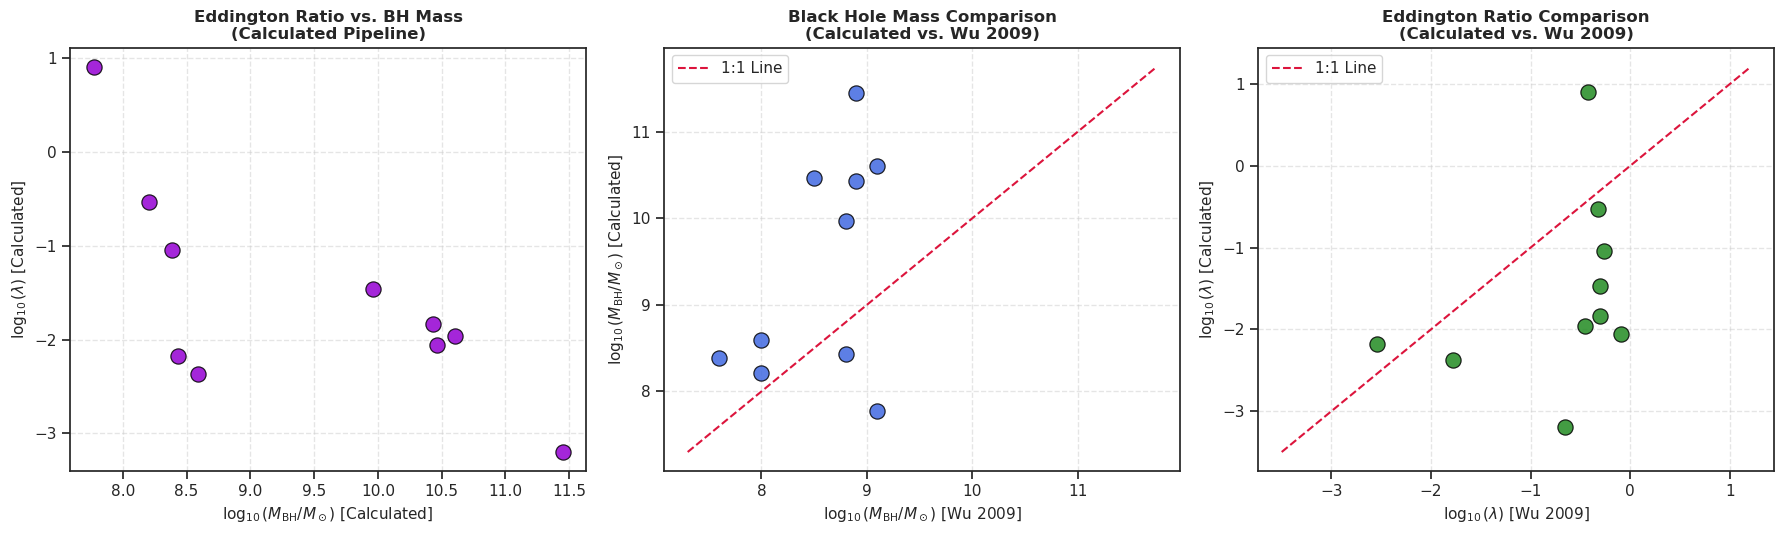

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean aesthetic styling for astronomy plots
sns.set_theme(style="ticks")
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# --- Plot 1: Obtained Eddington Ratio vs. Obtained Black Hole Mass ---
sns.scatterplot(
    data=select, x='log_mbh_calc', y='log_edd_ratio_calc', 
    color='darkviolet', s=120, edgecolor='black', alpha=0.85, ax=axes[0]
)
axes[0].set_title("Eddington Ratio vs. BH Mass\n(Calculated Pipeline)", fontsize=12, fontweight='bold')
axes[0].set_xlabel(r"$\log_{10}(M_{\mathrm{BH}} / M_\odot)$ [Calculated]", fontsize=11)
axes[0].set_ylabel(r"$\log_{10}(\lambda)$ [Calculated]", fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.5)

# --- Plot 2: Optional Mass Comparison (Calculated vs. Wu 2009) ---
sns.scatterplot(
    data=select, x='log_mbh', y='log_mbh_calc', 
    color='royalblue', s=120, edgecolor='black', alpha=0.85, ax=axes[1]
)
# Construct 1:1 perfect alignment reference line
mn_m, mx_m = min(select['log_mbh'].min(), select['log_mbh_calc'].min()) - 0.3, max(select['log_mbh'].max(), select['log_mbh_calc'].max()) + 0.3
axes[1].plot([mn_m, mx_m], [mn_m, mx_m], color='crimson', linestyle='--', linewidth=1.5, label='1:1 Line')
axes[1].set_title("Black Hole Mass Comparison\n(Calculated vs. Wu 2009)", fontsize=12, fontweight='bold')
axes[1].set_xlabel(r"$\log_{10}(M_{\mathrm{BH}} / M_\odot)$ [Wu 2009]", fontsize=11)
axes[1].set_ylabel(r"$\log_{10}(M_{\mathrm{BH}} / M_\odot)$ [Calculated]", fontsize=11)
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

# --- Plot 3: Optional Eddington Ratio Comparison (Calculated vs. Wu 2009) ---
sns.scatterplot(
    data=select, x='log_edd_ratio', y='log_edd_ratio_calc', 
    color='forestgreen', s=120, edgecolor='black', alpha=0.85, ax=axes[2]
)
# Construct 1:1 perfect alignment reference line
mn_e, mx_e = min(select['log_edd_ratio'].min(), select['log_edd_ratio_calc'].min()) - 0.3, max(select['log_edd_ratio'].max(), select['log_edd_ratio_calc'].max()) + 0.3
axes[2].plot([mn_e, mx_e], [mn_e, mx_e], color='crimson', linestyle='--', linewidth=1.5, label='1:1 Line')
axes[2].set_title("Eddington Ratio Comparison\n(Calculated vs. Wu 2009)", fontsize=12, fontweight='bold')
axes[2].set_xlabel(r"$\log_{10}(\lambda)$ [Wu 2009]", fontsize=11)
axes[2].set_ylabel(r"$\log_{10}(\lambda)$ [Calculated]", fontsize=11)
axes[2].legend()
axes[2].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()